# HOMEWORK 9

In this homework, I'm going to use the dlib face detector and apply it to images with faces.

### Step 0

Run the necessary imports.

In [9]:
import cv2
import dlib
import numpy as np
from matplotlib import pyplot as plt

# Устанавливаем размер графиков побольше, чтобы было лучше видно
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Load an image (any image that contains faces).

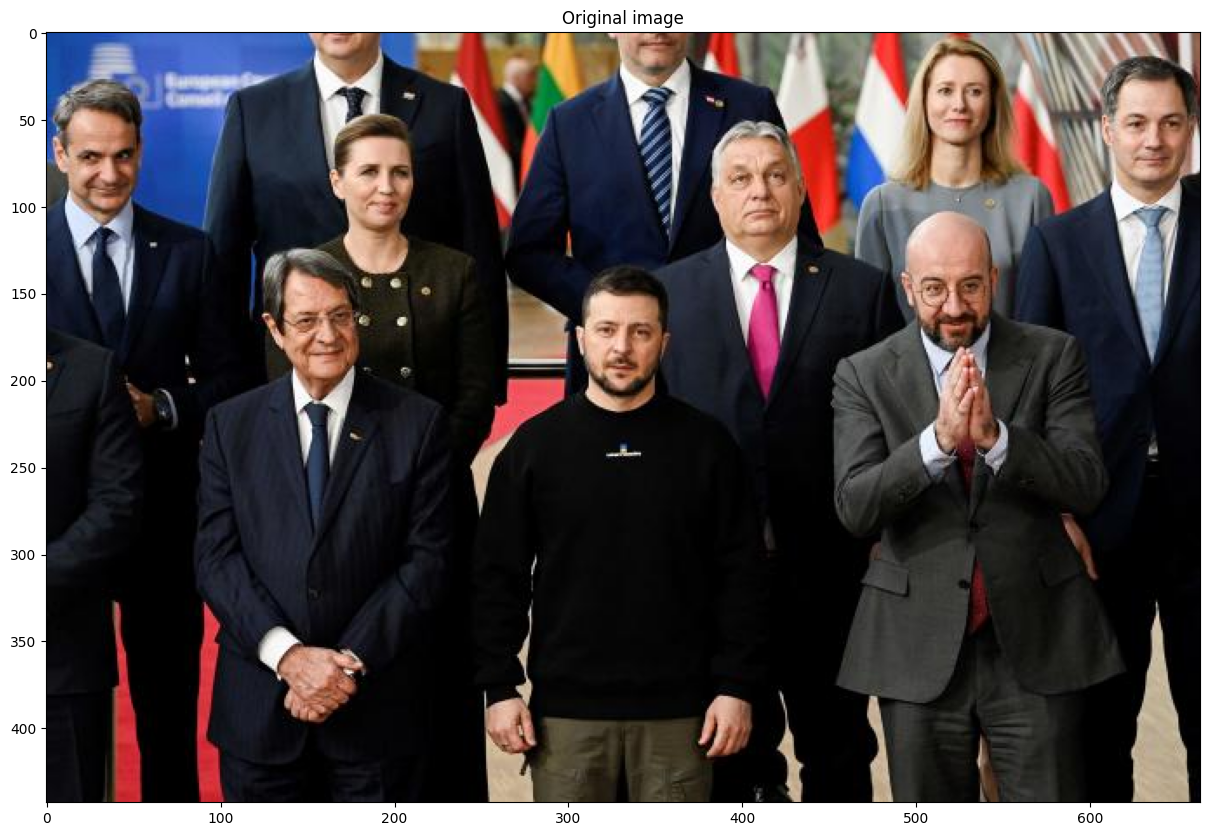

In [ ]:
img = cv2.imread('data/eu_summit.jpg')

# OpenCV читает изображения в формате BGR, а matplotlib ожидает RGB,
# поэтому нужно конвертировать, иначе цвета будут неправильными
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Также сделаем чёрно-белую версию, потому что детектор работает с градациями серого
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Показываем исходное изображение
plt.imshow(img)
plt.title('Original image')
plt.show()

### Step 2

Load the dlib face detector.

In [ ]:
# Загружаем детектор лиц из библиотеки dlib
detector = dlib.get_frontal_face_detector()
print('Детектор успешно загружен!')

Детектор успешно загружен!


In [ ]:
def rect_to_bb(rect):
    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y
    return (x, y, w, h)

### Step 3

Run the detector on the image.

In [ ]:
# Второй параметр (1) - это коэффициент увеличения (upsampling),
rects = detector(gray, 1)

print(f'Найдено лиц: {len(rects)}')

Найдено лиц: 8


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

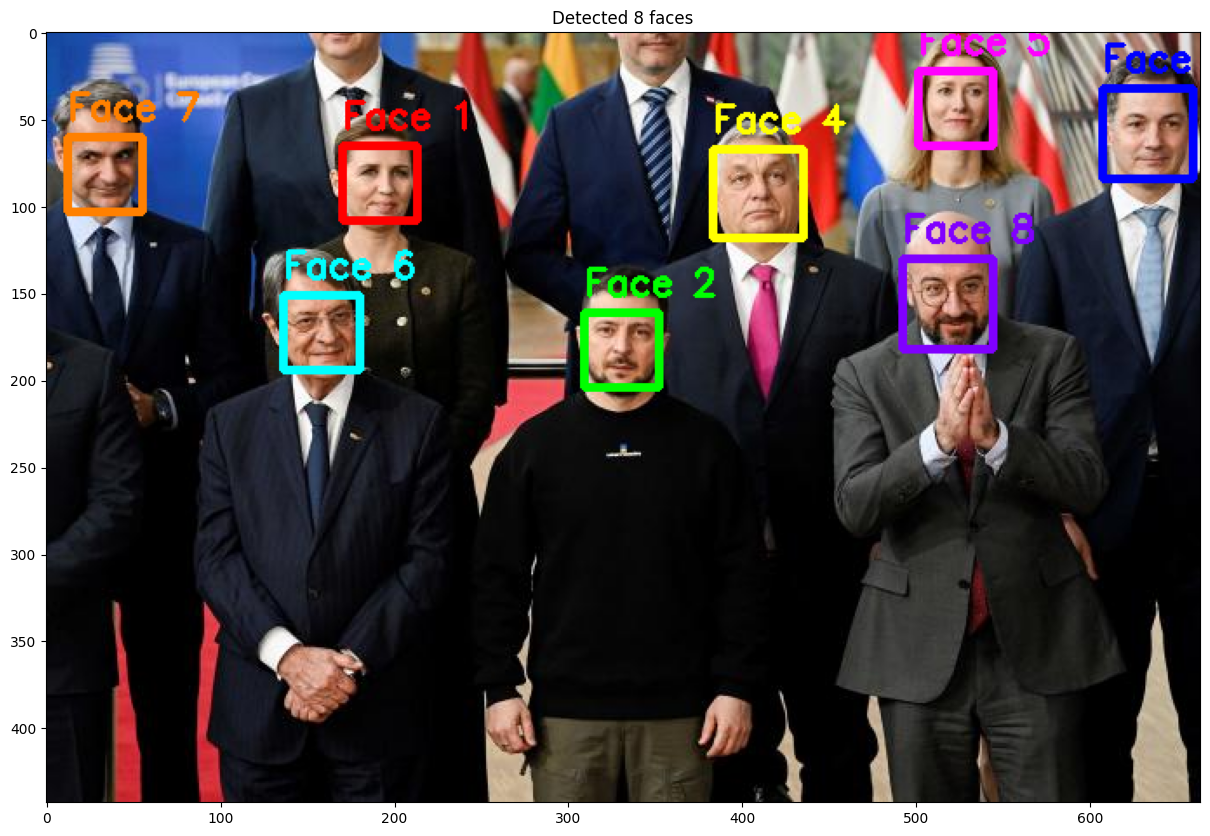

In [ ]:
result = np.copy(img)

# Список разных цветов для каждого лица
colors = [
    (255, 0, 0),      # красный
    (0, 255, 0),      # зелёный
    (0, 0, 255),      # синий
    (255, 255, 0),    # жёлтый
    (255, 0, 255),    # розовый
    (0, 255, 255),    # голубой
    (255, 128, 0),    # оранжевый
    (128, 0, 255),    # фиолетовый
    (0, 128, 255),    # небесно-голубой
    (255, 0, 128),    # малиновый
]

# Рисуем рамку вокруг каждого найденного лица
for i, rect in enumerate(rects):
    x, y, w, h = rect_to_bb(rect)
    # Выбираем цвет из списка (если лиц больше чем цветов, используем остаток от деления)
    color = colors[i % len(colors)]
    cv2.rectangle(result, (x, y), (x + w, y + h), color, 3)
    # Подписываем номер лица над рамкой
    cv2.putText(result, f'Face {i+1}', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

# Показываем результат
plt.imshow(result)
plt.title(f'Detected {len(rects)} faces')
plt.show()

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

Найдено лиц: 8


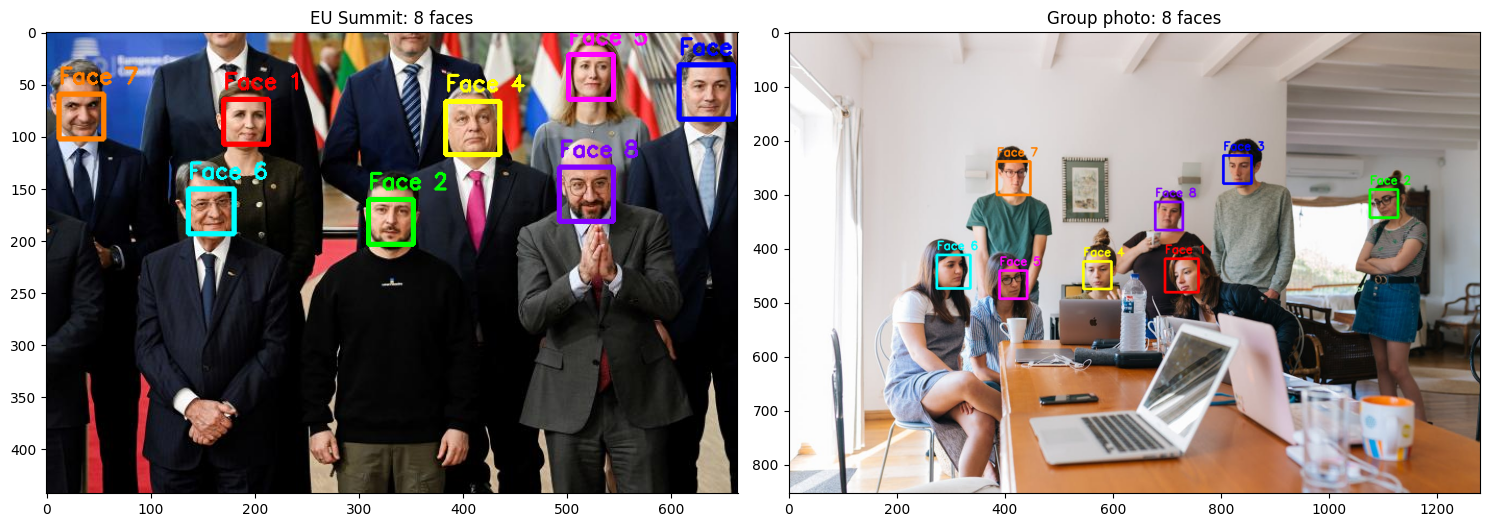

In [ ]:
# Теперь попробуем на более сложном изображении - групповое фото с большим количеством людей
img2 = cv2.imread('data/group_photo.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

# Запускаем детектор
rects2 = detector(gray2, 1)
print(f'Найдено лиц: {len(rects2)}')

# Рисуем рамки разными цветами
result2 = np.copy(img2)
for i, rect in enumerate(rects2):
    x, y, w, h = rect_to_bb(rect)
    color = colors[i % len(colors)]
    cv2.rectangle(result2, (x, y), (x + w, y + h), color, 3)
    cv2.putText(result2, f'Face {i+1}', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

# Показываем оба результата рядом для сравнения
plt.subplot(121)
plt.imshow(result)
plt.title(f'EU Summit: {len(rects)} faces')

plt.subplot(122)
plt.imshow(result2)
plt.title(f'Group photo: {len(rects2)} faces')

plt.tight_layout()
plt.show()

Group photo с upsampling=1: 8 лиц
Group photo с upsampling=2: 8 лиц


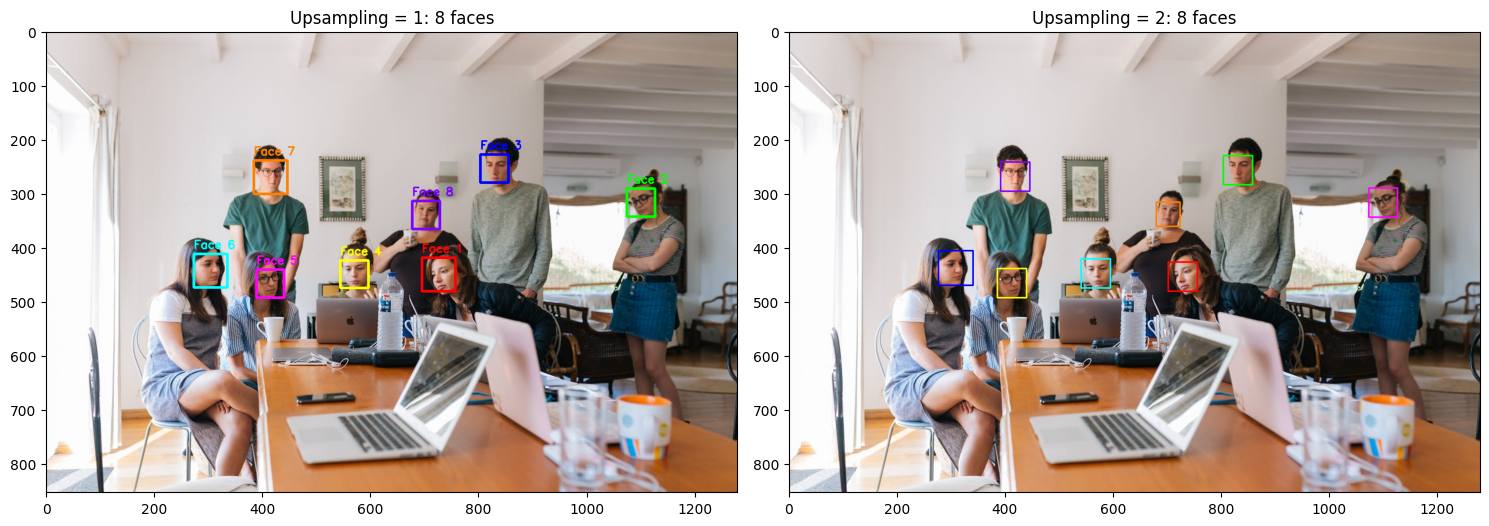

In [16]:
# Попробуем увеличить upsampling до 2, чтобы найти более мелкие лица на групповом фото
# Это увеличивает изображение, поэтому маленькие лица становятся больше и детектор их находит
rects_up = detector(gray2, 2)
print(f'Group photo с upsampling=1: {len(rects2)} лиц')
print(f'Group photo с upsampling=2: {len(rects_up)} лиц')

result_up = np.copy(img2)
for i, rect in enumerate(rects_up):
    x, y, w, h = rect_to_bb(rect)
    color = colors[i % len(colors)]
    cv2.rectangle(result_up, (x, y), (x + w, y + h), color, 2)

plt.subplot(121)
plt.imshow(result2)
plt.title(f'Upsampling = 1: {len(rects2)} faces')

plt.subplot(122)
plt.imshow(result_up)
plt.title(f'Upsampling = 2: {len(rects_up)} faces')

plt.tight_layout()
plt.show()

Детектор dlib хорошо справляется с обнаружением лиц